# 2 The SVD on Weather Data

In [ ]:
import numpy as np
from numpy.linalg import svd as svd
from numpy.linalg import matrix_rank as matrix_rank
import pandas as pd
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
from a03_helper import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


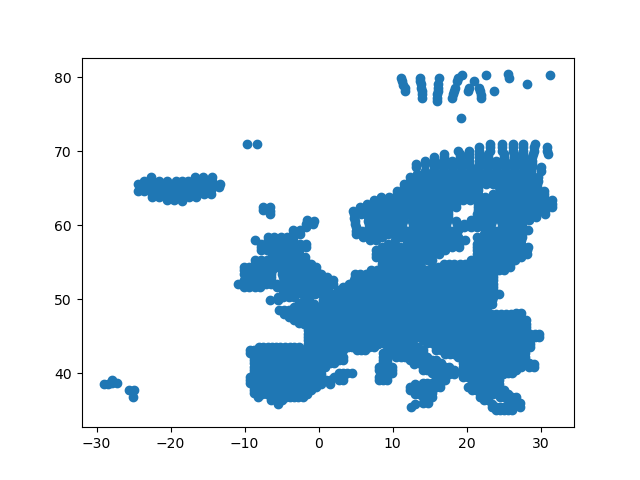

In [ ]:
# The date is being loaded via `a03_helper.py`
climate = pd.read_csv("data/worldclim.csv")
coord = pd.read_csv("data/worldclim_coordinates.csv")

# lon = coord["lon"]
# lat = coord["lat"]


# Plot the coordinates
plot_xy(lon, lat)

## 2a

In [ ]:
# YOUR PART
# Normalize the data to z-scores. Store the result in X.
# For this, complete the code in `a03_helper.py`.
X = (climate - climate.mean()) / climate.std()

print(f'Each feature circa mean = 0: {(X.mean().abs() < 1e-6).all()}')
print(f'Each feature circa standard deviation = 1:{(X.std().sub(1).abs() < 1e-6).all()}')

Each feature circa mean = 0: True
Each feature circa standard deviation = 1:True


/var/folders/z5/pr2ddd2n71l8kplp8zz0fklh0000gn/T/ipykernel_4931/2722728386.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  X.hist(ax=plt.gca())


array([[<Axes: title={'center': 'min1'}>,
        <Axes: title={'center': 'min2'}>,
        <Axes: title={'center': 'min3'}>,
        <Axes: title={'center': 'min4'}>,
        <Axes: title={'center': 'min5'}>,
        <Axes: title={'center': 'min6'}>,
        <Axes: title={'center': 'min7'}>],
       [<Axes: title={'center': 'min8'}>,
        <Axes: title={'center': 'min9'}>,
        <Axes: title={'center': 'min10'}>,
        <Axes: title={'center': 'min11'}>,
        <Axes: title={'center': 'min12'}>,
        <Axes: title={'center': 'max1'}>,
        <Axes: title={'center': 'max2'}>],
       [<Axes: title={'center': 'max3'}>,
        <Axes: title={'center': 'max4'}>,
        <Axes: title={'center': 'max5'}>,
        <Axes: title={'center': 'max6'}>,
        <Axes: title={'center': 'max7'}>,
        <Axes: title={'center': 'max8'}>,
        <Axes: title={'center': 'max9'}>],
       [<Axes: title={'center': 'max10'}>,
        <Axes: title={'center': 'max11'}>,
        <Axes: title={'cen

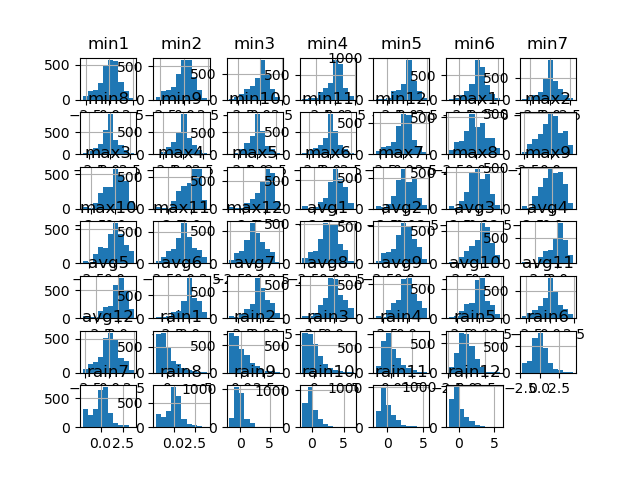

In [ ]:
# Plot histograms of attributes
nextplot()
X.hist(ax=plt.gca())

## 2b

In [ ]:
# Compute the SVD of the normalized climate data and store it in variables U,s,Vt. What
# is the rank of the data?
# YOUR PART
U, s, Vt = np.linalg.svd(X)
S = np.diag(s)

In [ ]:
rank_X = np.sum(s > 1e-10)
print(f'Rank: {rank_X}')

Rank: 48


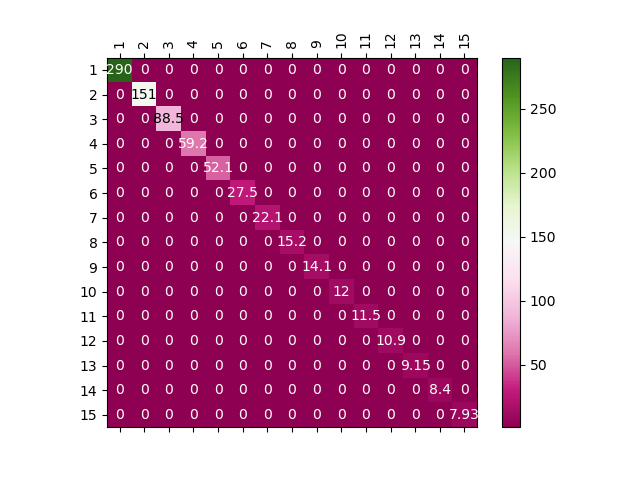

In [ ]:
# starting 15 singular values in the matrix S plot
plot_matrix(S[:15, :15], lim=(1, S.max()), rownames = range(1,16), colnames = range(1,16))

## 2c

In [ ]:
# Here is an example plot.
plot_xy(lon, lat, U[:, 0])

In [ ]:
# For interpretation, it may also help to look at the other component matrices and
# perhaps use other plot functions (e.g., plot_matrix).
# YOUR PART

## 2d

In [ ]:
# Here is an example.
plot_xy(U[:, 0], U[:, 1], lat - np.mean(lat))

## 2e

In [ ]:
# 2e(i) Guttman-Kaiser
# YOUR PART

In [ ]:
# 2e(ii) 90% squared Frobenius norm
# YOUR PART

In [ ]:
# 2e(iv) entropy
# YOUR PART

In [ ]:
# 2e(v) random flips
# Random sign matrix: np.random.choice([-1,1], X.shape)
# YOUR PART

## 2f

In [ ]:
# Here is the empty plot that you need to fill (one line per choice of Z: RSME between
# original X and the reconstruction from size-Z SVD of noisy versions)
# YOUR PART
nextplot()
plt.plot()
plt.xlabel(r"Noise level ($\epsilon$)")
plt.ylabel("Reconstruction RMSE vs. original data")